In [1]:
# ============================================================
#   CUSTOMER CHURN PREDICTION
#   CADES Hackathon | SRM Institute of Science & Technology
#   Team: shashank-kodali
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

DRIVE_PATH     = '/content/drive/MyDrive/Churn_Hackathon/'
DATA_PATH      = DRIVE_PATH + 'data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'
PROCESSED_PATH = DRIVE_PATH + 'data/processed/'

print("✅ Setup complete")

Mounted at /content/drive
✅ Setup complete


In [2]:
print("""
╔══════════════════════════════════════════════════════╗
║           PROBLEM STATEMENT                          ║
║                                                      ║
║  Customer churn is a major challenge for telecom     ║
║  companies. This system predicts whether a customer  ║
║  is likely to leave, using:                          ║
║    • Usage patterns                                  ║
║    • Subscription history                            ║
║    • Account information                             ║
║                                                      ║
║  OUTPUT: Churn prediction + Risk categorization      ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║           PROBLEM STATEMENT                          ║
║                                                      ║
║  Customer churn is a major challenge for telecom     ║
║  companies. This system predicts whether a customer  ║
║  is likely to leave, using:                          ║
║    • Usage patterns                                  ║
║    • Subscription history                            ║
║    • Account information                             ║
║                                                      ║
║  OUTPUT: Churn prediction + Risk categorization      ║
╚══════════════════════════════════════════════════════╝



In [3]:
df = pd.read_csv(DATA_PATH)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"📊 Dataset: {df.shape[0]} customers, {df.shape[1]} features")
print(f"🎯 Churn Rate: {(df['Churn']=='Yes').mean()*100:.1f}%")
print(f"✅ Missing Values: {df.isnull().sum().sum()}")
df.head(3)

📊 Dataset: 7043 customers, 21 features
🎯 Churn Rate: 26.5%
✅ Missing Values: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


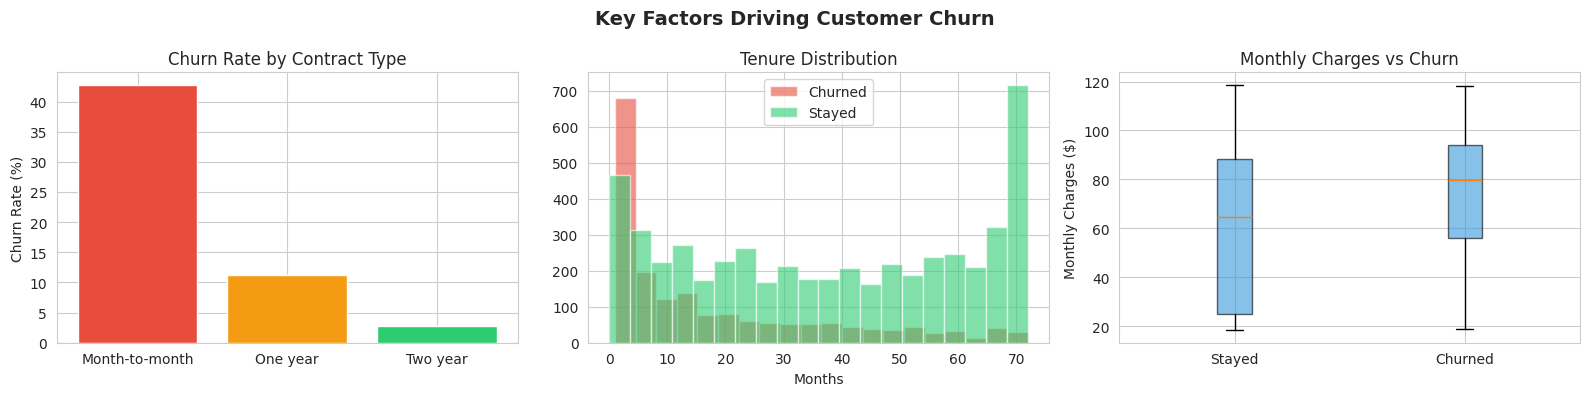


📌 Key Findings:
   • Month-to-month customers churn the most
   • New customers (low tenure) are highest risk
   • Higher monthly charges correlate with churn



In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Key Factors Driving Customer Churn', fontsize=14, fontweight='bold')

# Contract type
churn_contract = df.groupby('Contract')['Churn'].apply(
    lambda x: (x=='Yes').mean()*100).reset_index()
axes[0].bar(churn_contract['Contract'], churn_contract['Churn'],
            color=['#e74c3c','#f39c12','#2ecc71'])
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate (%)')

# Tenure
churned     = df[df['Churn']=='Yes']['tenure']
not_churned = df[df['Churn']=='No']['tenure']
axes[1].hist(churned, alpha=0.6, color='#e74c3c', label='Churned', bins=20)
axes[1].hist(not_churned, alpha=0.6, color='#2ecc71', label='Stayed', bins=20)
axes[1].set_title('Tenure Distribution')
axes[1].set_xlabel('Months')
axes[1].legend()

# Monthly Charges
axes[2].boxplot([df[df['Churn']=='No']['MonthlyCharges'],
                  df[df['Churn']=='Yes']['MonthlyCharges']],
                 labels=['Stayed', 'Churned'],
                 patch_artist=True,
                 boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[2].set_title('Monthly Charges vs Churn')
axes[2].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'data/key_insights.png', dpi=150)
plt.show()

print("""
📌 Key Findings:
   • Month-to-month customers churn the most
   • New customers (low tenure) are highest risk
   • Higher monthly charges correlate with churn
""")

In [5]:
# Load model and scaler
with open(PROCESSED_PATH + 'best_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open(PROCESSED_PATH + 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load test data
X_test = pd.read_csv(PROCESSED_PATH + 'X_test.csv')
y_test = pd.read_csv(PROCESSED_PATH + 'y_test.csv').squeeze()

# Predict
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print(f"✅ Model loaded: {type(model).__name__}")
print(f"✅ Predictions made on {len(X_test)} customers")

✅ Model loaded: LogisticRegression
✅ Predictions made on 1409 customers


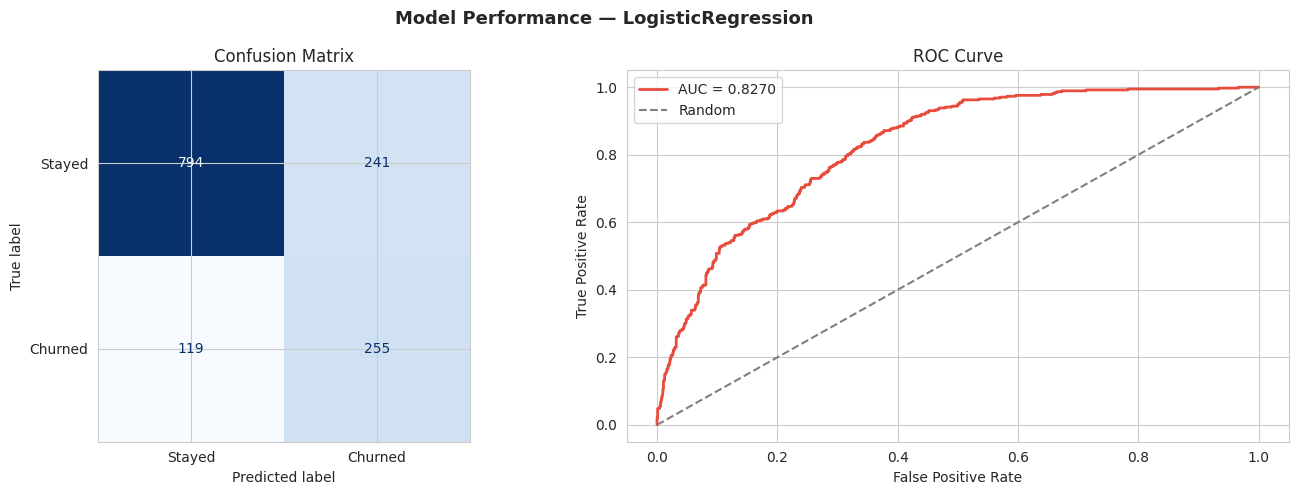


🏆 ROC-AUC Score: 0.8270
              precision    recall  f1-score   support

      Stayed       0.87      0.77      0.82      1035
     Churned       0.51      0.68      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.78      0.74      0.75      1409



In [6]:
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve)

auc = roc_auc_score(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Model Performance — {type(model).__name__}', fontsize=13, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Stayed','Churned']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'--', color='gray', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'data/demo_performance.png', dpi=150)
plt.show()

print(f"\n🏆 ROC-AUC Score: {auc:.4f}")
print(classification_report(y_test, y_pred, target_names=['Stayed','Churned']))

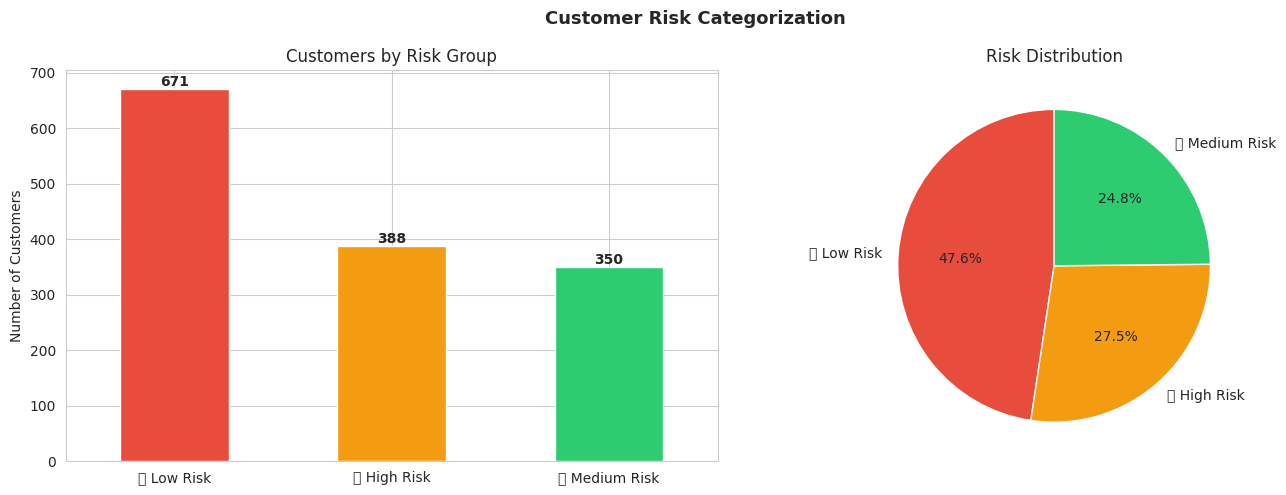


📊 Risk Summary:
   🟢 Low Risk: 671 customers (47.6%)
   🔴 High Risk: 388 customers (27.5%)
   🟡 Medium Risk: 350 customers (24.8%)


In [7]:
# Categorize customers into risk groups
def categorize_risk(prob):
    if prob >= 0.6:   return '🔴 High Risk'
    elif prob >= 0.3: return '🟡 Medium Risk'
    else:             return '🟢 Low Risk'

risk_series = pd.Series(y_prob).apply(categorize_risk)
risk_counts = risk_series.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Risk Categorization', fontsize=13, fontweight='bold')

# Bar chart
colors = ['#e74c3c', '#f39c12', '#2ecc71']
risk_counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Customers by Risk Group')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(risk_counts.index, rotation=0)
for i, v in enumerate(risk_counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(risk_counts, labels=risk_counts.index,
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Risk Distribution')

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'data/risk_demo.png', dpi=150)
plt.show()

print("\n📊 Risk Summary:")
for risk, count in risk_counts.items():
    pct = count / len(risk_series) * 100
    print(f"   {risk}: {count} customers ({pct:.1f}%)")

       LIVE CHURN PREDICTION DEMO

  Churn Prediction  : ✅  NO — Will Stay
  Churn Probability : 12.5%
  Risk Category     : 🟢 Low Risk



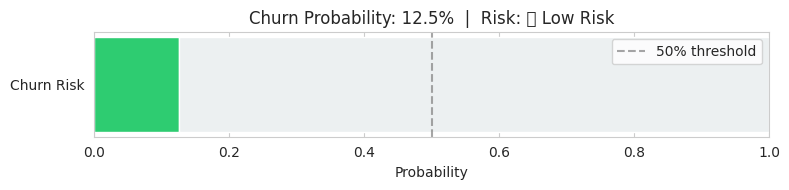

In [8]:
# Simulate predicting churn for a brand new customer
sample_customer = X_test.iloc[0:1].copy()  # take one customer from test set

prob   = model.predict_proba(sample_customer)[0][1]
pred   = model.predict(sample_customer)[0]
risk   = categorize_risk(prob)

print("=" * 50)
print("       LIVE CHURN PREDICTION DEMO")
print("=" * 50)
print(f"\n  Churn Prediction  : {'⚠️  YES — Will Churn' if pred == 1 else '✅  NO — Will Stay'}")
print(f"  Churn Probability : {prob*100:.1f}%")
print(f"  Risk Category     : {risk}")
print("\n" + "=" * 50)

# Probability gauge visualization
fig, ax = plt.subplots(figsize=(8, 2))
ax.barh(['Churn Risk'], [prob], color='#e74c3c' if prob > 0.5 else '#2ecc71', height=0.4)
ax.barh(['Churn Risk'], [1 - prob], left=[prob],
        color='#ecf0f1', height=0.4)
ax.set_xlim(0, 1)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='50% threshold')
ax.set_title(f'Churn Probability: {prob*100:.1f}%  |  Risk: {risk}')
ax.set_xlabel('Probability')
ax.legend()
plt.tight_layout()
plt.show()